## News Stream — Fine-Tuning Qwen3-4B with Unsloth (QLoRA)
### From dataset → training → GGUF (Ollama) + merged 16-bit (vLLM)

**Runtime:** Colab → change runtime type → **T4 GPU** (free tier is enough for a 4B model with QLoRA).

This notebook does five things:
1. Install Unsloth and load **Qwen3-4B** in 4-bit (QLoRA).
2. Attach LoRA adapters (the tiny trainable side-matrices).
3. Load your `news_stream_400_train.jsonl` / `_val.jsonl` and apply Qwen3's chat template.
4. Train, watching **train vs. validation loss**.
5. Export to **GGUF for Ollama** and **merged 16-bit for vLLM**.

> Mental model recap: the base model stays **frozen**. We only train small LoRA matrices (rank `r`), scaled by `alpha`. QLoRA means the frozen base is quantized to 4-bit so it fits in a T4's ~15 GB.

## 1. Install
Unsloth pins compatible versions of transformers/trl/peft for you. Pin Unsloth itself if you want reproducibility across class sessions — APIs move fast.

In [ ]:
# %%capture
!uv pip install -U unsloth unsloth_zoo
# If a class needs a frozen, reproducible setup, pin instead, e.g.:
# !pip install "unsloth==2026.5.*" "unsloth_zoo==2026.5.*"


Using Python 3.13.15 environment at: /usr
Resolved 101 packages in 855ms
Prepared 32 packages in 8.63s
Uninstalled 22 packages in 799ms
Installed 32 packages in 221ms
 + bitsandbytes==0.50.1
 - charset-normalizer==3.4.9
 + charset-normalizer==3.5.1
 - cuda-pathfinder==1.6.0
 + cuda-pathfinder==1.6.1
 + cut-cross-entropy==25.1.1
 - datasets==4.0.0
 + datasets==4.3.0
 - diffusers==0.39.0
 + diffusers==0.40.0
 - dill==0.3.8
 + dill==0.4.0
 - fsspec==2025.3.0
 + fsspec==2025.9.0
 + hf-transfer==0.1.9
 - huggingface-hub==1.27.0
 + huggingface-hub==1.28.0
 - idna==3.18
 + idna==3.19
 + msgspec==0.21.1
 - numpy==2.1.3
 + numpy==2.5.2
 - pandas==2.2.3
 + pandas==3.0.5
 - pillow==11.3.0
 + pillow==12.3.0
 - protobuf==5.29.6
 + protobuf==7.36.0
 - psutil==5.9.5
 + psutil==7.2.2
 - pyarrow==18.1.0
 + pyarrow==25.0.1
 - regex==2025.11.3
 + regex==2026.7.19
 - requests==2.32.4
 + requests==2.34.2
 - rich==13.9.4
 + rich==15.0.0
 - setuptools==75.2.0
 + setuptools==81.0.0
 + structlog==26.1.0
 - tor

### Restart Sessions (Control + M)
so numpy package mismatch will be taken care of

## 2. Load Qwen3-4B in 4-bit

- `max_seq_length = 2048`: our records carry a system menu, so they run a little longer than a bare prompt. 2048 is comfortable headroom.
- `load_in_4bit = True`: this is the **Q** in QLoRA — the frozen base is stored in 4-bit, cutting VRAM to ~a quarter.
- `dtype = None`: let Unsloth pick (bfloat16 on newer GPUs, float16 on T4).

In [ ]:
import unsloth

from unsloth import FastLanguageModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
# Cell 2
print("Torch:", torch.__version__)

import numpy
print("NumPy:", numpy.__version__)

Torch: 2.11.0+cu128
NumPy: 2.5.2


In [ ]:


max_seq_length = 1024
max_seq_length = 1024*2
# max_seq_length = 1024*4

dtype = None            # auto: bf16 where supported, else fp16
load_in_4bit = True     # QLoRA — 4-bit frozen base

In [ ]:


model, tokenizer = FastLanguageModel.from_pretrained(
    # model_name    = "unsloth/Qwen3-4B",   # Unsloth's 4-bit-ready Qwen3-4B
    # model_name    = "unsloth/Qwen3-0.6B",   # Unsloth's 4-bit-ready Qwen3-4B
    # model_name    = "unsloth/Qwen3-8B",   # Unsloth's 4-bit-ready Qwen3-4B
    # model_name    = "unsloth/Qwen3-14B",   # Unsloth's 4-bit-ready Qwen3-4B
    model_name    = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit",   # Unsloth's 4-bit-ready Qwen3-7B
    # model_name    = "unsloth/Llama-3.2-1B-Instruct-bnb-4bit",   # Unsloth's 4-bit-ready unsloth/Llama-3.2-1B-Instruct-bnb-4bit
    # model_name    = "unsloth/gemma-2-9b-bnb-4bit",   # Unsloth's 4-bit-ready unsloth/gemma-2-9b-bnb-4bit
    # model_name    = "unsloth/Meta-Llama-3.1-8B-Instruct-bnb-4bit",   # Unsloth's 4-bit-ready unsloth/gemma-2-9b-bnb-4bit
    max_seq_length = max_seq_length,
    dtype          = dtype,
    load_in_4bit   = load_in_4bit,
    # full_finetuning = False,   # default; we're doing LoRA
)


==((====))==  Unsloth 2026.8.19: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

## 3. Attach LoRA adapters

This is where the trainable parameters come from. Everything else stays frozen.

- **`r` (rank) = 16** — capacity of the side-matrices. 8 is fine for pure style; 16 gives a little more room for the persona + "use the provided menu" behaviour. Bigger = more capacity + more params.
- **`lora_alpha` = 16** — the scaling on the LoRA update. A common rule is alpha ≈ rank (some use 2×rank). The **alpha/rank ratio** sets the real strength.
- **`target_modules`** — which weight matrices get adapters. We hit both attention (`q,k,v,o`) and the feed-forward (`gate,up,down`) projections — the standard "all-linear" LoRA that gives the best quality.
- **`use_gradient_checkpointing = "unsloth"`** — trades a little compute for a lot of memory, so longer context fits on a T4.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,          # 0 is optimized in Unsloth
    bias = "none",             # optimized
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,        # try True later: scales alpha by 1/sqrt(r)
    loftq_config = None,
)


Unsloth 2026.8.19 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


## 4. Bring in your dataset

Upload `news_stream_400_train.jsonl` and `news_stream_400_val.jsonl` (left sidebar → Files → upload), or pull them from Google Drive / HF. Each line is already in the `messages` format:


In [ ]:
# from datasets import load_dataset

# train_dataset = load_dataset("json", data_files="multilingual_dataset.jsonl", split="train")

# print(train_dataset)
# print("example:", train_dataset[0]["messages"][1])   # a user turn


In [ ]:
from datasets import load_dataset

languages = [
    "odia",
    "hindi",
    "english",
    "telugu",
    "bengali",
    "tamil",
]

datasets = {}

for lang in languages:
    dataset_name = f"{lang}-{lang}"

    datasets[lang] = load_dataset(
        "csv",
        data_files={
            "train": f"hf://datasets/PMIndiaData/PMIndiaSum/{dataset_name}/train.csv",
            "validation": f"hf://datasets/PMIndiaData/PMIndiaSum/{dataset_name}/valid.csv",
            "test": f"hf://datasets/PMIndiaData/PMIndiaSum/{dataset_name}/test.csv",
        }
    )

    print(
        lang,
        len(datasets[lang]["train"]),
        len(datasets[lang]["validation"]),
        len(datasets[lang]["test"])
    )

odia-odia/train.csv: reconstructing file:   0%|          |  0.00B / 42.8MB            

odia-odia/train.csv: downloading bytes:           |  0.00B            

valid.csv:   0%|          | 0.00/566k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/590k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

test.csv:   0%|          | 0.00/685k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

tamil 5847 116 116


In [ ]:
def prepare_dataset(dataset, language):

    # dataset = dataset.rename_columns({
    #     "source": "text",
    #     "target": "summary"
    # })

    dataset = dataset.add_column(
        "language",
        [language] * len(dataset)
    )

    return dataset

In [ ]:
print(datasets)

{'odia': DatasetDict({
    train: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 4419
    })
    validation: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 116
    })
    test: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 116
    })
}), 'hindi': DatasetDict({
    train: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 7131
    })
    validation: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 116
    })
    test: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 116
    })
}), 'english': DatasetDict({
    train: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary'],
        num_rows: 7928
    })
    validation: Dataset({
        features: ['source_url', 'target_url', 'text', 'summary']

In [ ]:
import json

output_file = "multilingual_dataset.jsonl"

with open(output_file, "w", encoding="utf-8") as f:
    for language, dataset_dict in datasets.items():
        for split, dataset in dataset_dict.items():
            for row in dataset:
                record = {
                    "language": language,
                    "split": split,
                    "source_url": row["source_url"],
                    "target_url": row["target_url"],
                    "text": row["text"],
                    "summary": row["summary"],
                }

                f.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"Saved to: {output_file}")

Saved to: multilingual_dataset.jsonl


In [ ]:
import json
import random

random.seed(42)

for language, dataset_dict in datasets.items():

    output_file = f"{language}_43.jsonl"

    all_records = []

    for split, dataset in dataset_dict.items():
        for row in dataset:
            all_records.append({
                "language": language,
                "split": split,
                "source_url": row["source_url"],
                "target_url": row["target_url"],
                "text": row["text"],
                "summary": row["summary"],
            })

    selected_records = random.sample(
        all_records,
        min(444, len(all_records))
    )

    with open(output_file, "w", encoding="utf-8") as f:
        for record in selected_records:
            f.write(
                json.dumps(record, ensure_ascii=False) + "\n"
            )

    print(f"{language}: saved {len(selected_records)} records → {output_file}")

odia: saved 43 records → odia_43.jsonl
hindi: saved 43 records → hindi_43.jsonl
english: saved 43 records → english_43.jsonl
telugu: saved 43 records → telugu_43.jsonl
bengali: saved 43 records → bengali_43.jsonl
tamil: saved 43 records → tamil_43.jsonl


In [ ]:
for lang in languages:

    datasets[lang]["train"] = prepare_dataset(
        datasets[lang]["train"],
        lang
    )

    datasets[lang]["validation"] = prepare_dataset(
        datasets[lang]["validation"],
        lang
    )

    datasets[lang]["test"] = prepare_dataset(
        datasets[lang]["test"],
        lang
    )

In [ ]:
from datasets import concatenate_datasets

train_dataset = concatenate_datasets([
    datasets["english"]["train"],
    datasets["odia"]["train"],
    datasets["hindi"]["train"],
    datasets["telugu"]["train"],
    datasets["tamil"]["train"],
    datasets["bengali"]["train"],
])

In [ ]:
valid_dataset = concatenate_datasets([
    datasets["english"]["validation"],
    datasets["odia"]["validation"],
    datasets["hindi"]["validation"],
    datasets["telugu"]["validation"],
    datasets["tamil"]["validation"],
    datasets["bengali"]["validation"],
])

In [ ]:
test_dataset = concatenate_datasets([
    datasets["english"]["test"],
    datasets["odia"]["test"],
    datasets["hindi"]["test"],
    datasets["telugu"]["test"],
    datasets["tamil"]["test"],
    datasets["bengali"]["test"],
])

In [ ]:
from collections import Counter

print("TRAIN")
print(Counter(train_dataset["language"]))

print("\nVALIDATION")
print(Counter(valid_dataset["language"]))

print("\nTEST")
print(Counter(test_dataset["language"]))

TRAIN
Counter({'english': 7928, 'hindi': 7131, 'telugu': 5894, 'tamil': 5847, 'bengali': 5325, 'odia': 4419})

VALIDATION
Counter({'english': 116, 'hindi': 116, 'telugu': 116, 'tamil': 116, 'bengali': 116, 'odia': 116})

TEST
Counter({'english': 116, 'hindi': 116, 'telugu': 116, 'tamil': 116, 'bengali': 116, 'odia': 116})


### Apply Qwen3's chat template

Qwen3 uses **ChatML** under the hood (`<|im_start|>` / `<|im_end|>`). You don't write those tokens — you hand Unsloth the clean `messages` list and let `get_chat_template` + `apply_chat_template` wrap each conversation into the exact string Qwen3 was trained on.

`enable_thinking=False` keeps the empty `<think></think>` block out of training targets — for a support-agent persona we want direct replies, not reasoning traces.

In [ ]:



from unsloth.chat_templates import get_chat_template

# Qwen3 tokenizer
tokenizer = get_chat_template(
    tokenizer,
    chat_template="qwen3"
)


def format_chat(examples):

    messages_batch = []

    for text, summary, language in zip(
        examples["text"],
        examples["summary"],
        examples["language"]
    ):

        messages = [
            {
                "role": "user",
                "content": (
                    f"Summarize the following news in 40-45 words "
                    f"in {language}.\n\n"
                    f"News:\n{text}"
                )
            },
            {
                "role": "assistant",
                "content": summary
            }
        ]

        messages_batch.append(messages)

    formatted_texts = [
        tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=False,
            enable_thinking=False,
        )
        for messages in messages_batch
    ]

    return {
        "text": formatted_texts
    }


train_dataset = train_dataset.map(
    format_chat,
    batched=True
)

val_dataset = valid_dataset.map(
    format_chat,
    batched=True
)

print(train_dataset[0]["text"][:1000])

Map:   0%|          | 0/36544 [00:00<?, ? examples/s]

Map:   0%|          | 0/696 [00:00<?, ? examples/s]

<|im_start|>user
Summarize the following news in 40-45 words in english.

News:
The Union Cabinet chaired by the Prime Minister Shri Narendra Modi has approved the revamped Khelo India programme at a cost of Rs.1,756 crore for the period 2017-18 to 2019-20. This marks a watershed moment in the history of Indian sports, as the Programme aims at mainstreaming sport as a tool for individual development, community development, economic development and national development. The revamped Khelo India Programme would impact the entire sports ecosystem, including infrastructure, community sports, talent identification, coaching for excellence, competition structure and sports economy. Salient features: Some of the salient features of the Programme include: • an unprecedented Pan Indian Sports Scholarship scheme, which would cover 1,000 most talented young athletes each year across select sports disciplines. • Each athlete selected under the scheme shall receive an annual scholarship worth Rs. 5

Checking if the dataset is containing meaning full information within that max seq length. what is the spread.

In [ ]:
import numpy as np

def analyze_token_lengths(dataset, tokenizer, text_col="text", summary_col="summary"):
    lengths = []

    for row in dataset:
        text = row[text_col] or ""
        summary = row[summary_col] or ""

        combined = f"{text}\n{summary}"

        tokens = tokenizer(
            combined,
            add_special_tokens=True,
            truncation=False,
        )

        lengths.append(len(tokens["input_ids"]))

    lengths = np.array(lengths)

    print(f"Total samples : {len(lengths):,}")
    print(f"Min tokens    : {lengths.min():,}")
    print(f"Max tokens    : {lengths.max():,}")
    print(f"Mean tokens   : {lengths.mean():,.0f}")
    print(f"Median tokens : {np.median(lengths):,.0f}")

    print("\nCoverage:")
    for percentage in [50, 70, 80, 90, 95, 99]:
        length = int(np.percentile(lengths, percentage))
        print(
            f"{percentage:>2}% of data <= {length:,} tokens"
        )

    return lengths

Even better: check multiple lengths

This directly tells you how much data each max_seq_length would retain:

In [ ]:
def check_coverage(lengths, sequence_lengths=None):

    if sequence_lengths is None:
        sequence_lengths = [512, 768, 1024, 1536, 2048, 2560, 3072, 4096]

    total = len(lengths)

    print(f"{'Max Length':>12} | {'Samples Kept':>14} | {'Coverage':>10}")
    print("-" * 45)

    for max_len in sequence_lengths:
        kept = np.sum(lengths <= max_len)
        coverage = kept / total * 100

        print(
            f"{max_len:>12,} | "
            f"{kept:>14,} | "
            f"{coverage:>9.2f}%"
        )

Before changing max_seq_length, you should inspect the token-length distribution of text + summary and find the lengths covering 70%, 90%, 95% of your samples.

Assuming your dataset is in train_dataset and you have tokenizer

In [ ]:
train_lengths = analyze_token_lengths(
    train_dataset,
    tokenizer,
    text_col="text",
    summary_col="summary",
)

Total samples : 36,544
Min tokens    : 95
Max tokens    : 140,339
Mean tokens   : 3,432
Median tokens : 1,335

Coverage:
50% of data <= 1,335 tokens
70% of data <= 2,609 tokens
80% of data <= 4,193 tokens
90% of data <= 8,661 tokens
95% of data <= 14,412 tokens
99% of data <= 30,865 tokens


## 5. Trainer configuration

Every hyperparameter here maps to something we discussed:

- **`learning_rate = 2e-4`** — step size per weight update. LoRA's sweet spot. Loss jittering → lower it; barely moving → raise it.
- **`per_device_train_batch_size = 2` × `gradient_accumulation_steps = 4`** → **effective batch size 8**. The T4 can't hold 8 at once, so we accumulate 4 micro-batches of 2 and apply one combined update — big-batch stability, small-batch memory.
- **`num_train_epochs = 3`** — with ~352 rows, 2–3 passes is the sweet spot; more risks memorizing.
- **`eval_strategy = "steps"`** — this is what lets you *watch* train vs. val loss diverge (the overfitting fingerprint).
- **`warmup_steps`** — ramp the LR up gently so early updates don't thrash the weights.

In [ ]:
from trl import SFTTrainer, SFTConfig
train_small = train_dataset.shuffle(seed=42).select(
    range(min(6666, len(train_dataset)))
)

val_small = val_dataset.shuffle(seed=42).select(
    range(min(444, len(val_dataset)))
)
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    # train_dataset = train_dataset,
    # eval_dataset = val_dataset,
    train_dataset = train_small,
    eval_dataset = val_small,
    args = SFTConfig(
        dataset_text_field = "text",
        max_seq_length = max_seq_length,
        per_device_train_batch_size = 5,
        gradient_accumulation_steps = 4,     # effective batch = 8
        warmup_steps = 5,
        num_train_epochs = 2,
        learning_rate = 2e-5,
        # logging_steps = 5,
        eval_strategy = "steps",
        eval_steps = 40,                     # check val loss every 40 steps
        save_strategy = "steps",
        save_steps = 40,                     # Save val loss every 40 steps
        optim = "adamw_8bit",
        weight_decay = 0.01,
        save_total_limit=2,

        # ⭐ Best model configuration
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,

        logging_steps=10,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "none",
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/6666 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/444 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


# Early Stopping — Hugging Face Trainer

- **Purpose:** Stops training when **validation performance stops improving**.

- **`early_stopping_patience=2`:** Training stops after **2 consecutive evaluations** without improvement.

- **Prevents overfitting:** Helps prevent **overfitting** and saves **training time and GPU resources**.

- **Evaluation required:** Works when evaluation is enabled through `eval_strategy` in `TrainingArguments`.

- **Best model tracking:** Requires `metric_for_best_model` and `load_best_model_at_end=True` for proper best-model tracking.


In [ ]:
from transformers import EarlyStoppingCallback

trainer.add_callback(
    EarlyStoppingCallback(
        early_stopping_patience=2
    )
)

### Train only on the assistant's replies

Crucial for instruction tuning: we don't want the model spending capacity learning to *predict the customer's message or the menu*. `train_on_responses_only` masks the loss so gradients flow **only** from the assistant turns. For Qwen3/ChatML the turn markers are `<|im_start|>user\n` and `<|im_start|>assistant\n`.

In [ ]:
from unsloth.chat_templates import train_on_responses_only

trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part    = "<|im_start|>assistant\n",
)


Map (num_proc=2):   0%|          | 0/6666 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/6666 [00:00<?, ? examples/s]

Unsloth: Removed 2181 out of 6666 samples from train_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


Map (num_proc=2):   0%|          | 0/444 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/444 [00:00<?, ? examples/s]

Unsloth: Removed 131 out of 444 samples from eval_dataset where all labels were -100 (no response marker found, usually truncation). This prevents NaN loss during training.


### Good Luck for Training

In [ ]:
trainer_stats = trainer.train()


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,485 | Num Epochs = 3 | Total steps = 1,683
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss,Validation Loss
20,1.037132,0.961351


Filter:   0%|          | 0/313 [00:00<?, ? examples/s]

Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-20/tokenizer_config.json.


### Read the curves
Pull the logged history and plot **training vs. validation loss**. Healthy = both descend and stay close. The moment val flattens/rises while train keeps dropping → overfitting → stop or reduce epochs/rank. Great live demo for the class.

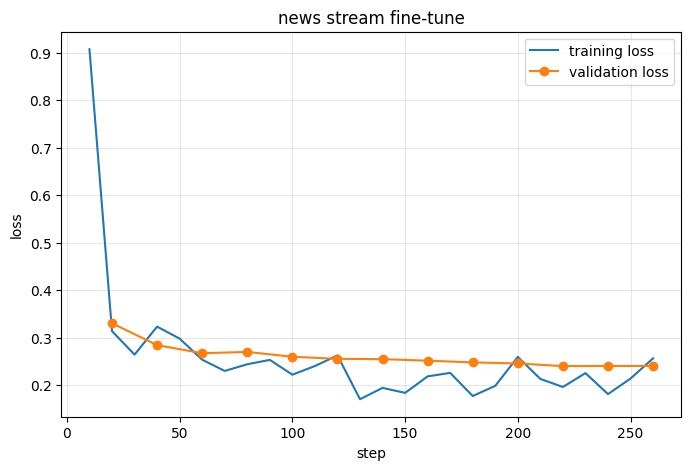

In [ ]:
import matplotlib.pyplot as plt

hist = trainer.state.log_history
tr = [(h["step"], h["loss"])      for h in hist if "loss" in h]
ev = [(h["step"], h["eval_loss"]) for h in hist if "eval_loss" in h]

plt.figure(figsize=(8,5))
if tr: plt.plot(*zip(*tr), label="training loss")
if ev: plt.plot(*zip(*ev), label="validation loss", marker="o")
plt.xlabel("step"); plt.ylabel("loss"); plt.legend(); plt.title("news stream fine-tune"); plt.grid(True, alpha=.3)
plt.show()


## 6. Quick sanity test (before export)
Switch to fast inference and talk to the model. Does it sound like news stream?

In [ ]:
NEWS_ARTICLE="""The PM CARES Fund, established in March 2020 amid the COVID-19 pandemic, has once again come under scrutiny over questions surrounding its transparency, accountability and access to information. The fund was created as a public charitable trust to respond to emergencies and provide assistance during situations such as public-health crises.

Questions surrounding the fund have existed since its creation. Critics and information seekers have raised concerns about whether details relating to its finances and functioning should be accessible under the Right to Information (RTI) framework. The debate has also extended to questions about parliamentary oversight and the extent to which information about the fund can be sought or discussed in legal proceedings.

A central issue is the legal status of PM CARES. According to its official website, the fund is registered as a Public Charitable Trust, rather than being described as a personal fund of the Prime Minister. The Prime Minister serves as its ex-officio chairperson, while the Ministers of Defence, Home Affairs and Finance are ex-officio trustees.

The fund says it receives voluntary contributions from individuals and organisations and does not receive budgetary support from the government. It can also receive foreign contributions under the applicable regulatory framework.

Another major point of discussion is auditing. The PM CARES website states that the fund is audited by an independent auditor appointed by its trustees. It identifies KKC & Associates LLP, Chartered Accountants, Mumbai, as the appointed auditor for a three-year period.

Fresh attention has followed the publication of more recent financial information. According to reporting on the fund's 2024–25 audit, PM CARES recorded receipts of approximately ₹8,452.95 crore, with the reported closing balance also around ₹8,452 crore as of March 31, 2025.

The controversy therefore revolves less around whether the fund exists and more around how much information about its functioning should be publicly accessible and what mechanisms should provide independent accountability.

As the debate continues, questions about RTI access, auditing, parliamentary scrutiny and the distinction between a public charitable trust and a government-controlled institution remain important parts of the wider discussion surrounding PM CARES.
"""

In [ ]:
FastLanguageModel.for_inference(model)

news = NEWS_ARTICLE

languages = [
    "English",
    "Hindi",
    "Telugu",
    "Tamil",
    "Bengali",
    "Odia",
]

for language in languages:

    messages = [
        {
            "role": "system",
            "content": (
                "You are a multilingual news article assistant. "
                "Consize news article around 43 words. "
                "Little explanatory. should cover complete essence of news "
            )
        },
        {
            "role": "user",
            "content": f"""
Language: {language}

Summarize the following news in approximately 40-45 words.

News:
{news}
"""
        },
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,
        return_tensors="pt",
        enable_thinking=False,
    ).to("cuda")

    out = model.generate(
        input_ids=inputs,
        # max_new_tokens=200,
        temperature=0.3,
        top_p=0.9,
    )

    response = tokenizer.decode(
        out[0][inputs.shape[-1]:],
        skip_special_tokens=True
    )

    print("=" * 70)
    print(f"LANGUAGE: {language}")
    print(response)

LANGUAGE: English
PM CARES Fund: Questions of transparency and accountability
LANGUAGE: Hindi
PM CARES Fund: Transparency, Accountability, and Access to Information
LANGUAGE: Telugu
PM CARES Fund: Transparency, Accountability and Access to Information
LANGUAGE: Tamil
PM CARES Fund: Transparency, Accountability and Access to Information
LANGUAGE: Bengali
PM CARES Fund: Transparency, accountability and access to information
LANGUAGE: Odia
PM CARES Fund: Questions of transparency and accountability


In [ ]:
FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "system",
        "content": (
            "You are a multilingual news summarization assistant. "
            "Summarize accurately without adding information."
            "Summarize the following news in approximately 40-45 words."
        )
    },
    {
        "role": "user",
        "content": """
Language: Odia

Summarize the following news in approximately 40-45 words.

News:
The Government of India today announced a new initiative to support farmers across the country, with a focus on improving agricultural productivity, strengthening rural livelihoods, and providing better access to modern farming resources. The programme will provide financial assistance to eligible farmers, along with modern agricultural equipment and improved access to quality seeds.

According to officials, the initiative is designed to help farmers adopt advanced farming practices and reduce production costs. The government will also encourage the use of modern technology, efficient irrigation methods, and improved crop-management techniques to increase yields.

Under the programme, farmers will receive support through designated government agencies and local agricultural departments. Officials said special attention would be given to small and marginal farmers who often face difficulties accessing expensive equipment and high-quality agricultural inputs.

The scheme will be implemented from next month, with awareness campaigns and registration facilities expected to be launched shortly. Farmers will be provided information about eligibility requirements, application procedures, and available benefits through government offices and digital platforms.

The government expects the initiative to improve farm productivity, increase farmers’ income, and strengthen the agricultural sector. Further details regarding funding, eligibility, and implementation guidelines are expected to be released before the programme begins.
"""
    }
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    enable_thinking=False,
).to("cuda")

out = model.generate(
    input_ids=inputs,
    # max_new_tokens=200,
    temperature=0.3,
    top_p=0.9,
)

response = tokenizer.decode(
    out[0][inputs.shape[-1]:],
    skip_special_tokens=True
).strip()

print(response)
print("Words:", len(response.split()))

Government announces new initiative to support farmers
Words: 7


In [ ]:
from unsloth import FastLanguageModel

FastLanguageModel.for_inference(model)

messages = [
    {
        "role": "system",
        "content": (
            "You are a multilingual news summarization assistant. "
            "Summarize news accurately and concisely. "
            "Generate approximately 40-45 words. "
            "Do not add information that is not present in the news."
        )
    },
    {
        "role": "user",
        "content": """Language: Telugu

Summarize the following news in approximately 40-45 words.

News:
ఆంధ్రప్రదేశ్ ప్రభుత్వం రాష్ట్రంలోని రైతులకు కొత్త పథకాన్ని ప్రకటించింది. "
ఈ పథకం ద్వారా రైతులకు వ్యవసాయ పరికరాలు, విత్తనాలు మరియు సబ్సిడీ అందించనున్నట్లు అధికారులు తెలిపారు. "
రాబోయే నెల నుంచి ఈ పథకం అమలు కానుంది."""
    },
]

inputs = tokenizer.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    enable_thinking=False,
).to("cuda")

out = model.generate(
    input_ids=inputs,
    # max_new_tokens=100,
    max_new_tokens=200,
    temperature=0.3,
    top_p=0.9,
)

response = tokenizer.decode(
    out[0][inputs.shape[-1]:],
    skip_special_tokens=True
)

print(response)

Both `max_new_tokens` (=200) and `max_length`(=40960) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ఆంధ్రప్రదేశ్ రైతులకు కొత్త పథకం


In [ ]:
word_count = len(response.split())

print(f"Word count: {word_count}")

Word count: 4


In [ ]:
response = tokenizer.decode(
    out[0][inputs.shape[-1]:],
    skip_special_tokens=True
).strip()

word_count = len(response.split())

print(response)
print(f"\nWord count: {word_count}")

ఆంధ్రప్రదేశ్ రైతులకు కొత్త పథకం

Word count: 4


In [ ]:
trainer.save_model("news-summary-model")
tokenizer.save_pretrained("news-summary-model")

Unsloth: Restored added_tokens_decoder metadata in news-summary-model/tokenizer_config.json.


('news-summary-model/tokenizer_config.json',
 'news-summary-model/chat_template.jinja',
 'news-summary-model/tokenizer.json')

## 7. Save the LoRA adapters (lightweight checkpoint)
Just the adapters — a few MB. Useful to keep, and to re-merge later without retraining.

In [ ]:
# model.save_pretrained("news_lora")          # local
# tokenizer.save_pretrained("news_lora")
# # model.push_to_hub("your-username/news-qwen3-lora", token="hf_...")   # optional


## 8. Export → GGUF for **Ollama**

`save_pretrained_gguf` merges the LoRA into the base, converts to GGUF via llama.cpp, and quantizes. Pick a quant:
- **`q4_k_m`** — best size/quality trade-off, the usual choice for laptops/edge.
- **`q8_0`** — larger, higher fidelity.
- **`f16`** — full precision GGUF (biggest).

This step compiles llama.cpp the first time, so give it a few minutes.

In [ ]:
# model.save_pretrained_gguf(
#     "news_gguf",
#     tokenizer,
#     quantization_method = "q4_k_m",   # try "q8_0" for higher fidelity
# )
# # Produces e.g. news_gguf/unsloth.Q4_K_M.gguf
# !ls -lh news_gguf
model.save_pretrained_gguf(
    "news_gguf",
    tokenizer,
    quantization_method = "q4_k_m",   # try "q8_0" for higher fidelity
)
# Produces e.g. news_gguf/unsloth.Q4_K_M.gguf
!ls -lh news_gguf


Unsloth: Merging model weights to 16-bit format...


config.json:   0%|          | 0.00/752 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/32.8k [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in news_gguf/tokenizer_config.json.


Found HuggingFace hub cache directory: /root/.cache/huggingface/hub


...

model-00002-of-00002.safetensors: downloading bytes:           |  0.00B            



Unsloth: Preparing safetensor model files: 100%|██████████| 2/2 [02:14<00:00, 67.21s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 2/2 [02:16<00:00, 68.41s/it]


Unsloth: Merge process complete. Saved to `/content/news_gguf`
Unsloth: Converting to GGUF format...
==((====))==  Unsloth: Conversion from HF to GGUF information
   \\   /|    [0] Installing llama.cpp might take 3 minutes.
O^O/ \_/ \    [1] Converting HF to GGUF f16 might take 3 minutes.
\        /    [2] Converting GGUF f16 to ['q4_k_m'] might take 10 minutes each.
 "-____-"     In total, you will have to wait at least 16 minutes.

Unsloth: Installing llama.cpp. This might take 3 minutes...
Unsloth: Installing prebuilt llama.cpp b10472-mix-4b653db (app-b10472-mix-4b653db-linux-x64-cpu.tar.gz) - skipping compilation.
Unsloth: Preparing converter script...
Unsloth: [1] Converting model into f16 GGUF format.
This might take 3 minutes...
Unsloth: Initial conversion completed! Files: ['news_gguf_gguf/qwen3-4b.F16.gguf']
Unsloth: [2] Converting GGUF f16 into q4_k_m. This might take 10 minutes...
Unsloth: Model files cleanup...
Unsloth: All GGUF conversions completed successfully!
Generated

### Run it in Ollama
Unsloth writes a `Modelfile` next to the GGUF with the correct Qwen3 chat template baked in. Two ways to use it:

**A) On a machine with Ollama installed** (your GCP L4 VM, or locally): download the `.gguf` + `Modelfile`, then:
```bash
ollama create news-stream -f Modelfile
ollama run news-stream

```

**B) Inside Colab** (to demo end-to-end):

In [ ]:
# Install + start Ollama inside Colab (demo only)
!curl -fsSL https://ollama.com/install.sh | sh
import subprocess, time
subprocess.Popen(["ollama", "serve"])
time.sleep(5)

# Unsloth auto-generates a Modelfile; if you need one manually, this works too:
modelfile = '''FROM ./news_gguf/unsloth.Q4_K_M.gguf
TEMPLATE """{{ if .System }}<|im_start|>system
{{ .System }}<|im_end|>
{{ end }}{{ if .Prompt }}<|im_start|>user
{{ .Prompt }}<|im_end|>
{{ end }}<|im_start|>assistant
{{ .Response }}<|im_end|>
"""
PARAMETER stop "<|im_end|>"
PARAMETER temperature 0.7
'''
open("news_gguf/Modelfile", "w").write(modelfile)

!cd news_gguf && ollama create news-stream -f Modelfile
!ollama run news-stream """Language: Telugu

Summarize the following news in approximately 40-45 words.

News:
ఆంధ్రప్రదేశ్ ప్రభుత్వం రాష్ట్రంలోని రైతులకు కొత్త పథకాన్ని ప్రకటించింది. "
ఈ పథకం ద్వారా రైతులకు వ్యవసాయ పరికరాలు, విత్తనాలు మరియు సబ్సిడీ అందించనున్నట్లు అధికారులు తెలిపారు. "
రాబోయే నెల నుంచి ఈ పథకం అమలు కానుంది."""


## 9. Export → merged 16-bit for **vLLM**

vLLM serves standard HF safetensors, **not** GGUF. So we merge the LoRA into the base at 16-bit precision with `save_method="merged_16bit"`. (`merged_4bit` also exists if you want a smaller, lower-fidelity artifact.)

In [ ]:
model.save_pretrained_merged(
    "news_merged_16bit",
    tokenizer,
    save_method = "merged_16bit",
)
!ls -lh news_merged_16bit
# Optional straight-to-Hub:
# model.push_to_hub_merged("your-username/news-qwen3", tokenizer, save_method="merged_16bit", token="hf_...")


### Serve with vLLM
On your GPU box (L4/A100), point vLLM at the merged folder:
```bash
pip install vllm
python -m vllm.entrypoints.openai.api_server \
    --model /path/to/news_merged_16bit \
    --served-model-name news-stream \
    --max-model-len 1024
```
Then it speaks the OpenAI API:
```bash
curl http://localhost:8000/v1/chat/completions -H "Content-Type: application/json" -d '{
  "model": "news-stream",
  "messages": [
    {"role":"system","content":"You are a news stream agent. Menu: Margherita ₹210, Cola ₹60. Use only this menu."},
    {"role":"user","content":"veg options?"}
  ]
}'
```

## 10. Get your files out of Colab
Zip and download, or push to Drive.

In [ ]:
from google.colab import files
!zip -r news_gguf.zip news_gguf
!zip -r news_merged_16bit.zip news_merged_16bit
files.download("news_gguf.zip")
# files.download("news_merged_16bit.zip")   # large — Drive is usually better


---
### Recap: which artifact for what
| Target | Method | Output | Serve with |
|---|---|---|---|
| **Ollama / laptop / edge** | `save_pretrained_gguf(..., "q4_k_m")` | `.gguf` + `Modelfile` | `ollama create` / `ollama run` |
| **vLLM / GPU serving** | `save_pretrained_merged(..., "merged_16bit")` | HF safetensors folder | `vllm ... --model <folder>` |
| **Re-use / re-merge later** | `save_pretrained("news_lora")` | LoRA adapters (MB) | reload + merge |

**Teaching note:** GGUF is quantized-for-CPU/edge; the vLLM path stays 16-bit for GPU throughput. Same fine-tune, two deployment targets — a clean way to show students that *training* and *serving format* are separate decisions.